# HNW & SWE Validation Stats — all calibrated parameter sets

Reads every row from `opt_results_summary.csv`, instantiates `SnowToSwe` with the
calibrated parameters, runs the full Mag25 multi-station simulation, computes HNW
and SWE validation metrics (**no plots**), and writes the augmented table to
`opt_results_summary_validated.csv`.

| Added column | Description |
|---|---|
| `SWE_RMSE` / `HNW_RMSE` | Root-mean-squared error |
| `SWE_Bias` / `HNW_Bias` | Mean (model minus obs) |
| `SWE_Rel_BIAS` / `HNW_Rel_BIAS` | Relative bias |
| `SWE_R2` / `HNW_R2` | Nash-Sutcliffe R2 |
| `SWE_N` / `HNW_N` | Valid obs-model pairs |

Rows with missing parameters (NA) are skipped; their metric columns remain `NaN`.

In [13]:
import sys, os, warnings
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

BASE_DIR = Path('/Users/jakobwerkgarner/code/mt_dsnow')
os.chdir(BASE_DIR)

from plot_style import apply_style, C, SUBSET_COLOR
apply_style()

import HNW_validation.HNW_validation_helper as val_helper

# Active SNOWPACK subset context for coloring in downstream plots
color_data = 'BELOW_2000'
_subset_color_map = {
    'ALL': SUBSET_COLOR.ALL,
    'RAIN_GAUGE': SUBSET_COLOR.RAIN_GAUGE,
    'BELOW_2000': SUBSET_COLOR.BELOW_2000,
}


active_sp_color = _subset_color_map.get(str(color_data).upper(), C.SNOWPACK)

# Shared dataset palette used by plotting cells
PALETTE = {
    'SNOWPACK': active_sp_color,
    'Win21': C.WINKLER,
    'Rain_Gauge': SUBSET_COLOR.RAIN_GAUGE,
    'BELOW_2000': SUBSET_COLOR.BELOW_2000,
    'ALL': SUBSET_COLOR.ALL,
}

sys.path.insert(0, str(BASE_DIR / 'snow_to_swe_master'))
from main import SnowToSwe

MAG25_NC = str(BASE_DIR / 'calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc')
OPT_CSV  = str(BASE_DIR / 'calibration/AA_opt_out/Win21/res/opt_results_summary.csv')
OUT_CSV  = str(BASE_DIR / 'calibration/AA_opt_out/Win21/res/opt_results_summary_validated.csv')
PLOTS_DIR = BASE_DIR / 'calibration/AA_opt_out/Win21/plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PAR_COLS = ['rho_max', 'rho_null', 'eta_null', 'k', 'tau', 'c_ov', 'k_ov']

print('Imports OK')
print(f'Mag25     : {MAG25_NC}')
print(f'Opt CSV   : {OPT_CSV}')
print(f'Plots dir : {PLOTS_DIR}')
print(f'color_data: {color_data}  -> active SP color: {active_sp_color}')

Imports OK
Mag25     : /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc
Opt CSV   : /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/res/opt_results_summary.csv
Plots dir : /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/plots
color_data: BELOW_2000  -> active SP color: #D2AACE


---
## Load Mag25 and build task list (shared across all runs)

In [14]:
Mag25_data = xr.open_dataset(MAG25_NC)
Mag25_data = Mag25_data.drop_sel(station='Weisfluh_Joch')

times        = pd.to_datetime(Mag25_data['time'].values)
hyd_year     = np.where(times.month > 8, times.year, times.year - 1)
winter_years = np.unique(hyd_year)
station_list = Mag25_data['station'].values
hs_by_stn    = {s: Mag25_data['HS'].sel(station=s).values for s in station_list}

tasks = []
for stn in station_list:
    hs_full = hs_by_stn[stn]
    for y in winter_years:
        mask     = hyd_year == y
        time_idx = times[mask].values
        hs_vals  = hs_full[mask]
        tasks.append((stn, int(y), time_idx, hs_vals))

print(f'Stations         : {len(station_list)}')
print(f'Hydrological yrs : {len(winter_years)}  ({winter_years[0]}-{winter_years[-1]})')
print(f'Tasks per run    : {len(tasks)}')

Stations         : 40
Hydrological yrs : 6  (2016-2021)
Tasks per run    : 240


---
## Worker and pipeline helpers

In [15]:
def _process_station_winter(station_name, winter_year, time_idx, hs_values, snow_to_swe):
    """Run SnowToSwe on ONE station x ONE hydrological year (Sep-Aug)."""
    import warnings as _w, numpy as _np, pandas as _pd
    _w.filterwarnings('ignore')
    try:
        hs = _pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None
        if hs.iloc[0]  != 0: hs.iloc[0]  = 0.0
        if hs.iloc[-1] != 0: hs.iloc[-1] = 0.0
        swe_list = snow_to_swe.convert_list(hs.tolist(), timestep=24, verbose=False)
        if swe_list is None:
            return None
        swe_arr = _np.asarray(swe_list, dtype=float)
        assert swe_arr.shape[0] == len(hs)
        return (station_name, winter_year, time_idx, swe_arr)
    except Exception as e:
        return ('__ERROR__', station_name, f'winter {winter_year}: {e}')


def run_swe_pipeline(snow_to_swe, tasks, Mag25_data, n_jobs=-1):
    """
    Run SnowToSwe for all station x winter tasks (parallel).
    Returns (HNW_val, SWE_val) filtered to days with observed values.
    """
    results = Parallel(n_jobs=n_jobs)(
        delayed(_process_station_winter)(stn, y, tidx, hsv, snow_to_swe)
        for (stn, y, tidx, hsv) in tasks
    )

    ds = Mag25_data.copy()
    ds['SWE_mod'] = xr.full_like(ds['HS'], np.nan)

    for r in results:
        if r is None:
            continue
        if isinstance(r, tuple) and r[0] == '__ERROR__':
            continue
        stn, _, time_idx, swe_arr = r
        ds['SWE_mod'].loc[dict(station=stn, time=time_idx)] = swe_arr

    hnw_mod = ds['SWE_mod'].diff(dim='time').clip(min=0)
    ds['HNW_mod'] = hnw_mod.reindex(time=ds['time'])

    all_df = (
        ds[['HNW', 'HNW_mod', 'SWE', 'SWE_mod']]
        .to_dataframe()
        .reset_index()
        .rename(columns={'HNW': 'HNW_obs', 'SWE': 'SWE_obs'})
    )

    SWE_val = all_df[all_df['SWE_obs'].notna()].copy()
    HNW_val = all_df[all_df['HNW_obs'].notna()].copy()
    HNW_val.index = pd.to_datetime(HNW_val['time']).values

    return HNW_val, SWE_val



# Reference metrics extracted from images
hs2swe_swe_rmse = 32.1
deltasnow_swe_rmse = 33.9
hs2swe_hnw_relbias = 0.03
deltasnow_hnw_relbias = -0.17


print('Helpers defined.')

Helpers defined.


---
## Load calibration results

In [16]:
opt = pd.read_csv(OPT_CSV, na_values=['NA'])
has_params = opt[PAR_COLS].notna().all(axis=1)

print(f'Total rows       : {len(opt)}')
print(f'With full params : {has_params.sum()}')
print(f'Missing params   : {(~has_params).sum()}  -> will be skipped')

opt[['dataset', 'algorithm', 'phase', 'best_value'] + PAR_COLS]

Total rows       : 6
With full params : 6
Missing params   : 0  -> will be skipped


,dataset,algorithm,phase,best_value,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov
0,Win21,Nelder-Mead,1B,3.383,401.3,185,9.376e+06,0.02993,0.2268,0.0005105,0.3786
1,Win21,Nelder-Mead,2C,2.595,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786
2,Win21,Nelder-Mead,2B,2.067,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786
3,Win21,Nelder-Mead,3A,1.141,401.3,81.19,9.376e+06,0.02993,0.02362,0.0005105,0.785
4,Win21,Nelder-Mead,2A,1.538,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786
5,Win21,Nelder-Mead,1A,0.7452,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786


---
## Run SnowToSwe for every parameter set

For each row with valid parameters:
1. Instantiate `SnowToSwe` with the calibrated values.
2. Run the parallel station x winter pipeline.
3. Call `compute_metrics_hnw_swe` (no plots).

In [17]:
METRIC_KEYS = ['RMSE', 'Bias', 'Rel_BIAS', 'R2', 'N']
NAN_METRICS = {f'{v}_{m}': np.nan
               for v in ('SWE', 'HNW') for m in METRIC_KEYS}

all_metrics = []

for idx, row in tqdm(opt.iterrows(), total=len(opt), desc='Parameter sets'):

    if row[PAR_COLS].isna().any():
        all_metrics.append({'_idx': idx, **NAN_METRICS})
        continue

    snow_to_swe = SnowToSwe(
        rho_max  = float(row['rho_max']),
        rho_null = float(row['rho_null']),
        eta_null = float(row['eta_null']),
        k        = float(row['k']),
        tau      = float(row['tau']),
        c_ov     = float(row['c_ov']),
        k_ov     = float(row['k_ov']),
    )

    HNW_val, SWE_val = run_swe_pipeline(snow_to_swe, tasks, Mag25_data)

    stats = val_helper.compute_metrics_hnw_swe(
        hnw_df             = HNW_val,
        swe_df             = SWE_val,
        drop_weisfluh_joch = True,
        full_season        = False,
    )

    row_m = {'_idx': idx}
    for var in ('SWE', 'HNW'):
        for metric, val in stats[var].items():
            row_m[f'{var}_{metric}'] = val

    tqdm.write(
        f"  {idx:>3d}  {str(row['dataset']):<9s} {str(row['algorithm']):<12s}"
        f"  w=({row['w_SWE_NRMSE']:.2g}/{row['w_RHO_NRMSE']:.2g}/{row['w_SWE_NBIAS']:.2g})"
        f"  opt={row['best_value']:.4g}"
        f"  SWE_RMSE={row_m['SWE_RMSE']:.2f} \n HNW_rel_bias={row_m['HNW_Rel_BIAS']:.2f}"
    )

    all_metrics.append(row_m)

print('\nAll done.')

Parameter sets:   0%|          | 0/6 [00:00<?, ?it/s]

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


Parameter sets:  17%|█▋        | 1/6 [00:20<01:40, 20.20s/it]

    0  Win21     Nelder-Mead   w=(0/1/0)  opt=3.383  SWE_RMSE=55.35 
 HNW_rel_bias=-0.00
This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


Parameter sets:  33%|███▎      | 2/6 [00:54<01:53, 28.47s/it]

...

    3  Win21     Nelder-Mead   w=(0.6/0.2/0.2)  opt=1.141  SWE_RMSE=34.94 
 HNW_rel_bias=-0.20
This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


Parameter sets:  83%|████████▎ | 5/6 [02:46<00:35, 35.53s/it]

    4  Win21     Nelder-Mead   w=(0.7/0.3/0)  opt=1.538  SWE_RMSE=61.08 
 HNW_rel_bias=-0.29
This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'


Parameter sets: 100%|██████████| 6/6 [03:23<00:00, 33.86s/it]

    5  Win21     Nelder-Mead   w=(1/0/0)  opt=0.7452  SWE_RMSE=61.08 
 HNW_rel_bias=-0.29

All done.


---
## Merge metrics back and save

In [18]:
metrics_df = pd.DataFrame(all_metrics).set_index('_idx')

opt_out = opt.drop(columns=[c for c in opt.columns if c in metrics_df.columns]).copy()
opt_out = opt_out.join(metrics_df)

opt_out.to_csv(OUT_CSV, index=False)
print(f'Saved -> {OUT_CSV}')
print(f'Shape  : {opt_out.shape}')

metric_cols = [c for c in opt_out.columns
               if c.startswith('SWE_') or c.startswith('HNW_')]
preview_cols = ['dataset', 'algorithm', 'w_SWE_NRMSE', 'phase'] + metric_cols

pd.set_option('display.float_format', lambda x: f'{x:.4g}')
pd.set_option('display.max_columns', 30)
opt_out[preview_cols]

Saved -> /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/res/opt_results_summary_validated.csv
Shape  : (6, 31)


,dataset,algorithm,w_SWE_NRMSE,phase,SWE_RMSE,SWE_Bias,SWE_Rel_BIAS,SWE_R2,SWE_N,HNW_RMSE,HNW_Bias,HNW_Rel_BIAS,HNW_R2,HNW_N
0,Win21,Nelder-Mead,0,1B,55.35,-11.13,-0.05598,0.7937,1054,8.963,-0.003029,-0.00148,-0.5687,35409
1,Win21,Nelder-Mead,0.3,2C,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
2,Win21,Nelder-Mead,0.5,2B,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
3,Win21,Nelder-Mead,0.6,3A,34.94,-11.16,-0.05617,0.9178,1054,3.003,-0.4156,-0.2031,0.8238,35409
4,Win21,Nelder-Mead,0.7,2A,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
5,Win21,Nelder-Mead,1,1A,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409


---
## Calibration score vs validation RMSE

Saved plot -> /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/plots/validation_score_vs_metrics.png


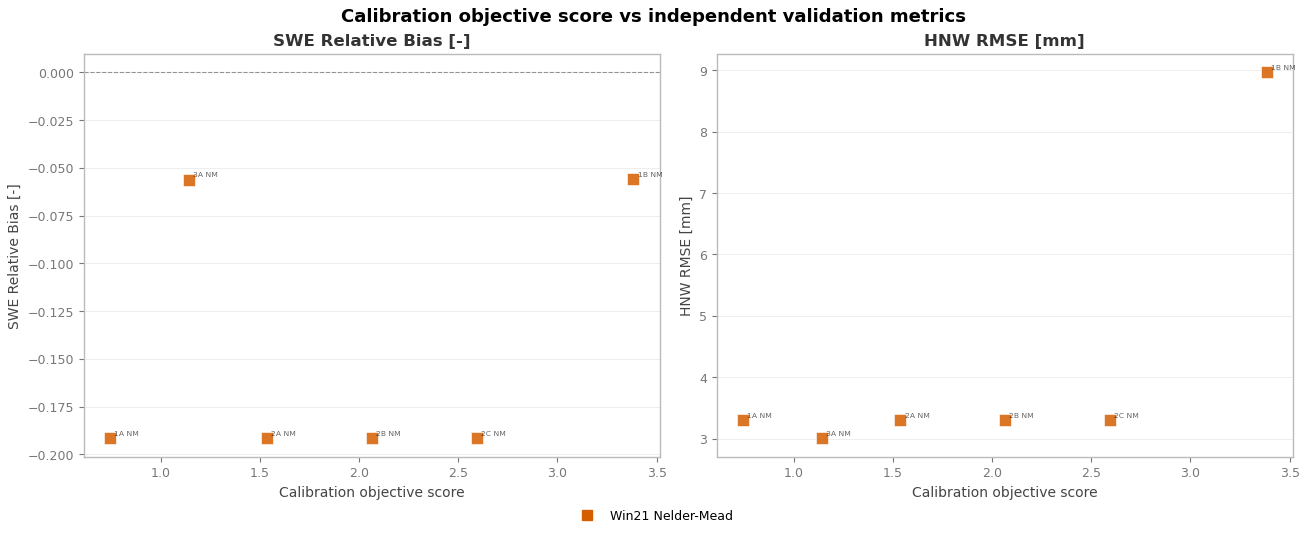

In [19]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

apply_style()

MARKERS = {'DE': 'o', 'Nelder-Mead': 's'}
ALG_SHORT = {'DE': 'DE', 'Nelder-Mead': 'NM'}

valid = opt_out.dropna(subset=['SWE_Rel_BIAS', 'HNW_RMSE', 'best_value']).copy()
DATASETS = sorted(valid['dataset'].unique())
ALGS     = sorted(valid['algorithm'].dropna().unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
fig.suptitle('Calibration objective score vs independent validation metrics',
             fontweight='bold', fontsize=13)

for ax, (metric, ylabel) in zip(axes, [
    ('SWE_Rel_BIAS', 'SWE Relative Bias [-]'),
    ('HNW_RMSE',     'HNW RMSE [mm]'),
]):
    for ds in DATASETS:
        for alg in ALGS:
            sub = valid[(valid['dataset'] == ds) & (valid['algorithm'] == alg)]
            if sub.empty:
                continue
            ax.scatter(
                sub['best_value'],
                sub[metric],
                color=PALETTE.get(ds, C.OBS),
                marker=MARKERS.get(alg, 'o'),
                s=70,
                alpha=0.85,
                edgecolors='white',
                linewidths=0.5,
                zorder=3,
            )
            for _, r in sub.iterrows():
                phase = r.get('phase') if pd.notna(r.get('phase')) else '?'
                lbl = f"{phase} {ALG_SHORT.get(r['algorithm'], r['algorithm'])}"
                ax.annotate(lbl, (r['best_value'], r[metric]),
                            fontsize=5.5, xytext=(3, 2),
                            textcoords='offset points', alpha=0.6)
    if metric == 'SWE_Rel_BIAS':
        ax.axhline(0, color=C.OBS, lw=0.8, ls='--', alpha=0.45)
    ax.set_xlabel('Calibration objective score')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')

handles = [
    Line2D([0], [0], color=PALETTE.get(ds, C.OBS), marker=MARKERS[a],
           ls='None', markersize=7, label=f'{ds} {a}')
    for ds in DATASETS for a in ALGS
]
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           fontsize=9, bbox_to_anchor=(0.5, -0.06), frameon=False)

out_path = PLOTS_DIR / 'validation_score_vs_metrics.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight')
print(f'Saved plot -> {out_path}')

plt.show()

## Best parameter set per group (lowest SWE RMSE)

In [20]:
valid_rows = opt_out.dropna(subset=['SWE_RMSE', 'HNW_Rel_BIAS']).copy()
# Rank each metric within dataset x algorithm group (lower is better for both)
valid_rows['_rank_swe'] = valid_rows.groupby(['dataset', 'algorithm'])['SWE_RMSE'] \
                                    .rank(method='min')
valid_rows['_rank_hnw'] = valid_rows.groupby(['dataset', 'algorithm'])['HNW_Rel_BIAS'] \
                                    .transform(lambda x: x.abs()).rank(method='min')
valid_rows['_rank_combined'] = valid_rows['_rank_swe'] + valid_rows['_rank_hnw']
best = (
    valid_rows
    .loc[valid_rows.groupby(['dataset', 'algorithm'])['_rank_combined'].idxmin()]
    [['dataset', 'algorithm', 'phase', 'w_SWE_NRMSE', 'w_RHO_NRMSE', 'w_SWE_NBIAS',
      'best_value'] + PAR_COLS + metric_cols]
    .sort_values(['dataset', 'algorithm'])
    .reset_index(drop=True)
)
from IPython.display import display
display(best.T)

,0
dataset,Win21
algorithm,Nelder-Mead
phase,1B
w_SWE_NRMSE,0
w_RHO_NRMSE,1
w_SWE_NBIAS,0
best_value,3.383
rho_max,401.3
rho_null,185
eta_null,9.376e+06


In [21]:
opt_out_sorted = opt_out.sort_values(
    by='HNW_Rel_BIAS',
    key=lambda s: s.abs(),
    ascending=True
)

opt_out_sorted = opt_out_sorted.drop(columns=['iterations', 'convergence', 'source_ctime', 'source_path'])
opt_out_sorted

,dataset,phase,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,w_RHO_NBIAS,w_SWE_KGE,w_RHO_KGE,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov,best_value,SWE_RMSE,SWE_Bias,SWE_Rel_BIAS,SWE_R2,SWE_N,HNW_RMSE,HNW_Bias,HNW_Rel_BIAS,HNW_R2,HNW_N
0,Win21,1B,Nelder-Mead,0,1,0,0,0,0,401.3,185,9.376e+06,0.02993,0.2268,0.0005105,0.3786,3.383,55.35,-11.13,-0.05598,0.7937,1054,8.963,-0.003029,-0.00148,-0.5687,35409
3,Win21,3A,Nelder-Mead,0.6,0.2,0.2,0,0,0,401.3,81.19,9.376e+06,0.02993,0.02362,0.0005105,0.785,1.141,34.94,-11.16,-0.05617,0.9178,1054,3.003,-0.4156,-0.2031,0.8238,35409
1,Win21,2C,Nelder-Mead,0.3,0.7,0,0,0,0,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786,2.595,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
2,Win21,2B,Nelder-Mead,0.5,0.5,0,0,0,0,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786,2.067,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
4,Win21,2A,Nelder-Mead,0.7,0.3,0,0,0,0,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786,1.538,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409
5,Win21,1A,Nelder-Mead,1,0,0,0,0,0,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786,0.7452,61.08,-38.11,-0.1918,0.7487,1054,3.308,-0.5871,-0.2869,0.7864,35409


Saved plot -> /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/plots/top_10_metrics.png


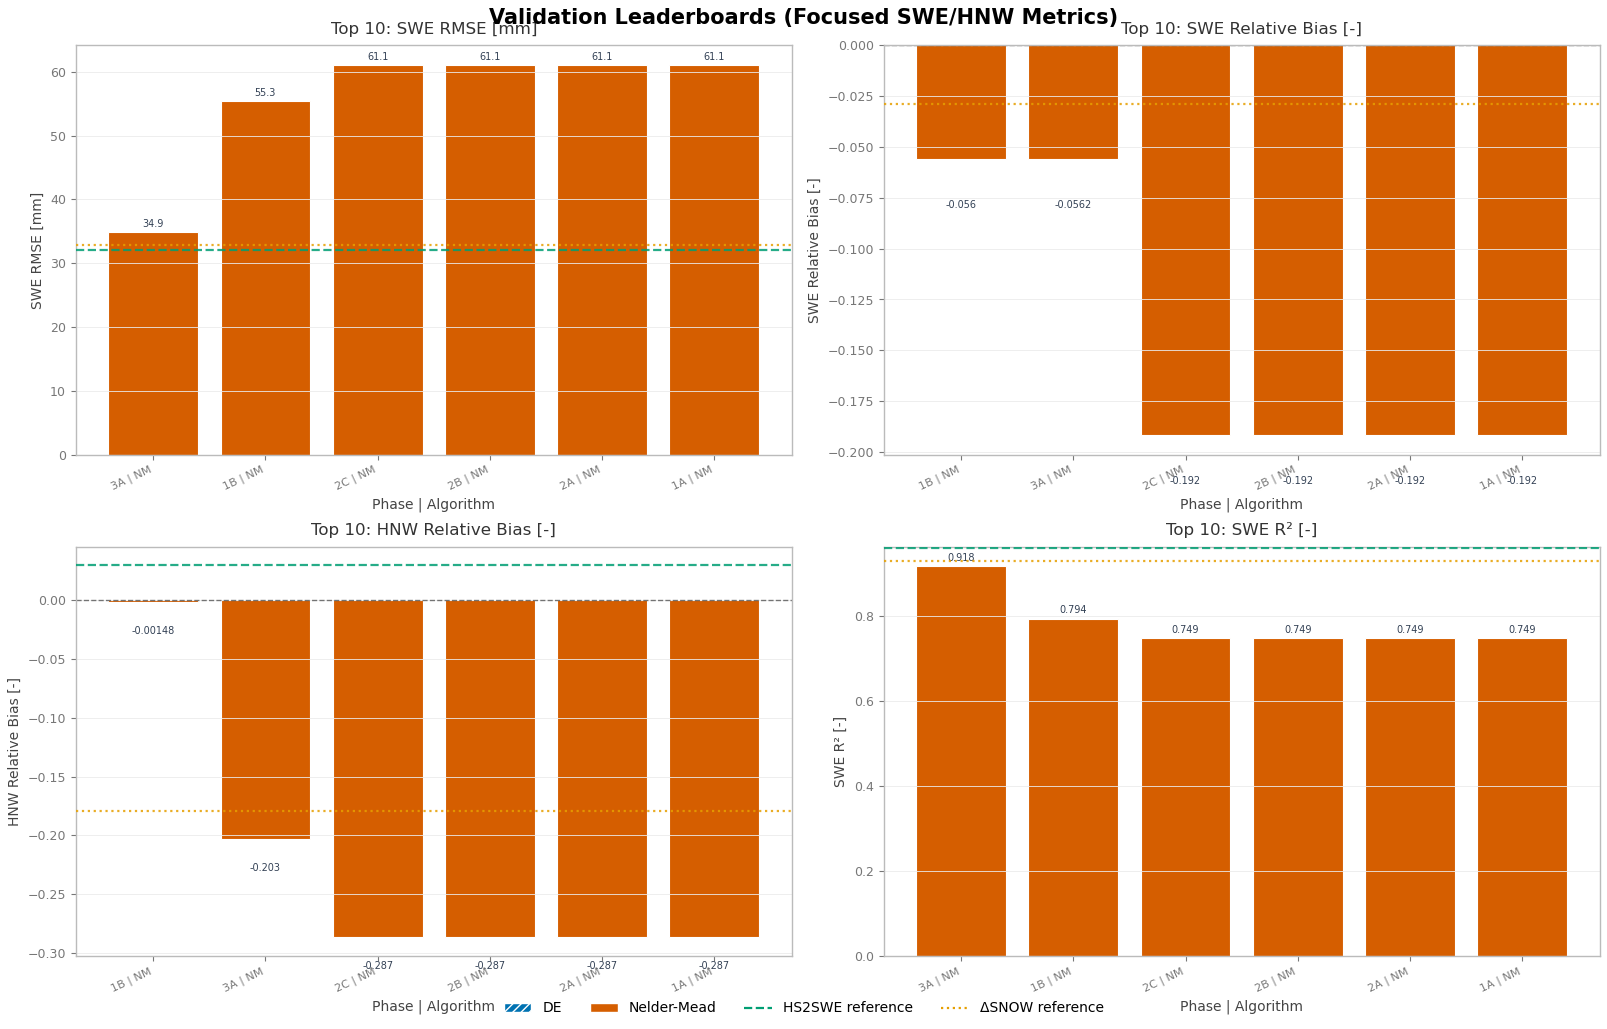

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import apply_style, C, HATCH

apply_style()

metrics = [
    ('SWE_RMSE',     'SWE RMSE [mm]',          'lower'),
    ('SWE_Rel_BIAS', 'SWE Relative Bias [-]',   'abs_lower'),
    ('HNW_Rel_BIAS', 'HNW Relative Bias [-]',   'abs_lower'),
    ('SWE_R2',       'SWE R² [-]',              'higher'),
]

# Reference values extracted from paper figures
ref_values = {
    'SWE_RMSE':     {'HS2SWE': 32.1,  'DELTASNOW': 32.8},
    'SWE_Rel_BIAS': {'HS2SWE': None,   'DELTASNOW': -0.029},
    'HNW_Rel_BIAS': {'HS2SWE': 0.03,   'DELTASNOW': -0.179},
    'SWE_R2':       {'HS2SWE': 0.96,   'DELTASNOW': 0.93},
}

ref_styles = {
    'HS2SWE':    {'color': C.HS2SWE, 'linestyle': '--', 'linewidth': 1.6},
    'DELTASNOW': {'color': C.DSNOW,  'linestyle': ':',  'linewidth': 1.6},
}



alg_palette = {'DE': C.MAGNUSSON, 'Nelder-Mead': C.WINKLER}
alg_hatch   = {'DE': HATCH.DE, 'Nelder-Mead': HATCH.NM}
alg_short   = {'DE': 'DE', 'Nelder-Mead': 'NM'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

for ax, (metric, ylabel, rule) in zip(axes, metrics):
    d = valid[['phase', 'algorithm', metric]].dropna().copy()

    if rule == 'abs_lower':
        d['_sort'] = d[metric].abs()
        ascending = True
    elif rule == 'higher':
        d['_sort'] = d[metric]
        ascending = False
    else:
        d['_sort'] = d[metric]
        ascending = True

    top10 = d.sort_values('_sort', ascending=ascending).head(10).copy()
    top10 = top10.reset_index(drop=True)

    x = np.arange(len(top10))
    colors = top10['algorithm'].map(alg_palette).fillna(C.HS).tolist()
    bars = ax.bar(
        x,
        top10[metric].to_numpy(),
        color=colors,
        edgecolor='white',
        linewidth=0.8,
    )

    for bar, alg in zip(bars, top10['algorithm'].astype(str)):
        bar.set_hatch(alg_hatch.get(alg, ''))

    x_labels = [
        f"{p} | {alg_short.get(a, a)}"
        for p, a in zip(top10['phase'].astype(str), top10['algorithm'].astype(str))
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=25, ha='right', fontsize=8)
    ax.set_title(f"Top 10: {ylabel}", pad=8)
    ax.set_xlabel('Phase | Algorithm')
    ax.set_ylabel(ylabel)

    if 'Rel_BIAS' in metric:
        ax.axhline(0, color=C.OBS, lw=1.0, ls='--', alpha=0.6)

    refs = ref_values.get(metric, {})
    for model_name, val in refs.items():
        if val is not None:
            style = ref_styles[model_name]
            ax.axhline(
                val,
                color=style['color'],
                linestyle=style['linestyle'],
                linewidth=style['linewidth'],
                alpha=0.85,
                zorder=6,
                label=f"{model_name} ref ({val})"
            )

    for b in bars:
        v = b.get_height()
        y = v + (0.008 * max(1.0, np.nanmax(np.abs(top10[metric]))))
        if v < 0:
            y = v - (0.02 * max(1.0, np.nanmax(np.abs(top10[metric]))))
        ax.text(
            b.get_x() + b.get_width() / 2,
            y,
            f"{v:.3g}",
            ha='center',
            va='bottom' if v >= 0 else 'top',
            fontsize=7,
            color='#334155',
        )

legend_handles = [
    Patch(facecolor=alg_palette['DE'], edgecolor='white', hatch=alg_hatch['DE'], label='DE'),
    Patch(facecolor=alg_palette['Nelder-Mead'], edgecolor='white', hatch=alg_hatch['Nelder-Mead'], label='Nelder-Mead'),
    Line2D([0], [0], color=C.HS2SWE, linestyle='--', linewidth=1.6, label='HS2SWE reference'),
    Line2D([0], [0], color=C.DSNOW, linestyle=':', linewidth=1.6, label='ΔSNOW reference'),
]
fig.legend(
    legend_handles, [h.get_label() for h in legend_handles],
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=10,
)

fig.suptitle(
    'Validation Leaderboards (Focused SWE/HNW Metrics)',
    fontsize=15,
    fontweight='bold',
    y=1.01,
)

out_path = PLOTS_DIR / 'top_10_metrics.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight')
print(f'Saved plot -> {out_path}')

plt.show()

In [23]:
def get_phase_settings(phase, df=opt_out, dataset=None, algorithm=None, as_dict=False):
    """
    Return all w_* columns and calibrated parameter values for a given phase.
    Example: get_phase_settings('2A')
    """
    par_cols = PAR_COLS if 'PAR_COLS' in globals() else [
        'rho_max', 'rho_null', 'eta_null', 'k', 'tau', 'c_ov', 'k_ov'
    ]
    w_cols = [c for c in df.columns if c.startswith('w_')]

    out_cols = ['dataset', 'phase', 'algorithm'] + w_cols + par_cols
    out_cols = [c for c in out_cols if c in df.columns]

    sub = df[df['phase'].astype(str).str.upper() == str(phase).upper()].copy()

    if dataset is not None:
        sub = sub[sub['dataset'].astype(str) == str(dataset)]
    if algorithm is not None:
        sub = sub[sub['algorithm'].astype(str) == str(algorithm)]

    if sub.empty:
        return [] if as_dict else pd.DataFrame(columns=out_cols)

    result = sub[out_cols].reset_index(drop=True)
    return result.to_dict(orient='records') if as_dict else result


# Example
get_phase_settings('2A')

,dataset,phase,algorithm,w_SWE_NRMSE,w_RHO_NRMSE,w_SWE_NBIAS,w_RHO_NBIAS,w_SWE_KGE,w_RHO_KGE,rho_max,rho_null,eta_null,k,tau,c_ov,k_ov
0,Win21,2A,Nelder-Mead,0.7,0.3,0,0,0,0,401.3,81.4,9.376e+06,0.2331,0.02362,0.0005105,0.3786


Saved plot -> /Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Win21/plots/top_10_bar.png


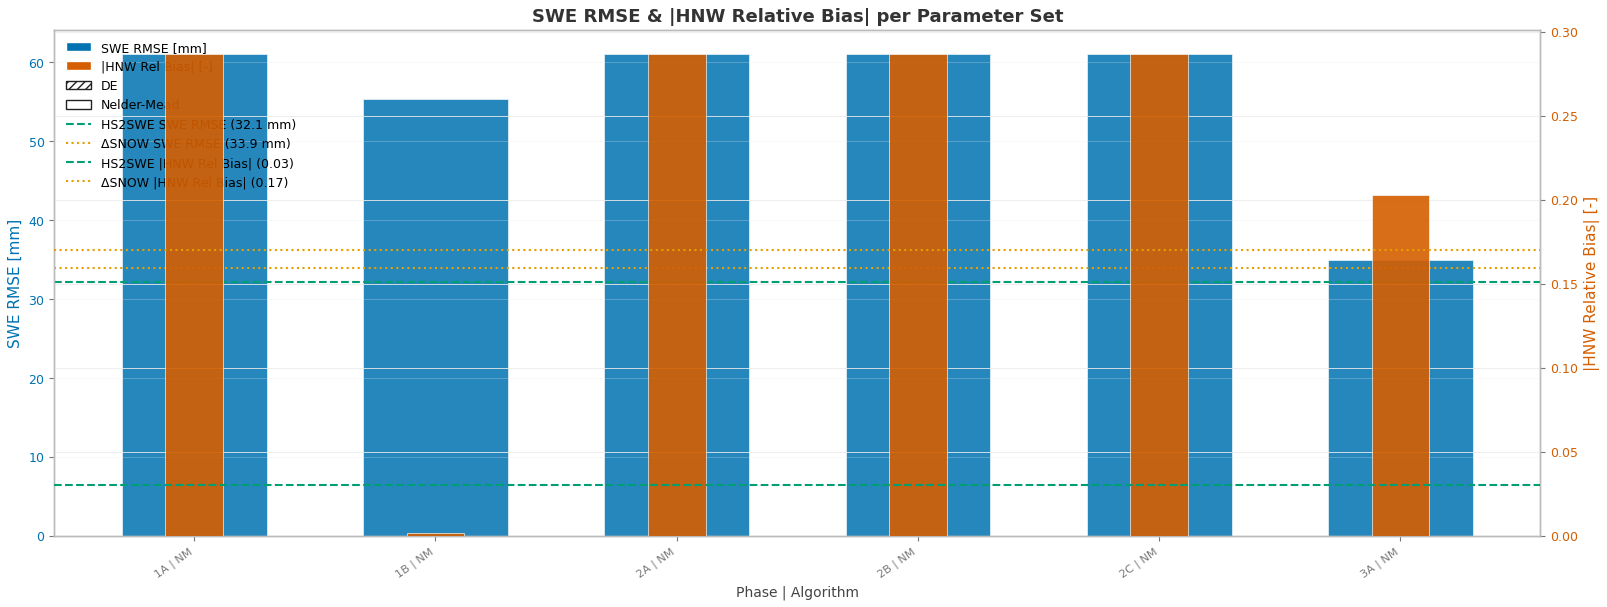

In [24]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import apply_style, C, HATCH
apply_style()

valid_sorted = valid.copy()
valid_sorted = valid_sorted.sort_values('phase').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6), constrained_layout=True)

x = np.arange(len(valid_sorted))
width = 0.6

alg_hatch = {'DE': HATCH.DE, 'Nelder-Mead': HATCH.NM}

bars_swe = ax.bar(
    x,
    valid_sorted['SWE_RMSE'],
    width,
    label='SWE RMSE [mm]',
    color=C.MAGNUSSON,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5,
)

ax2 = ax.twinx()
bars_hnw = ax2.bar(
    x,
    valid_sorted['HNW_Rel_BIAS'].abs(),
    width * 0.4,
    label='|HNW Rel Bias| [-]',
    color=C.WINKLER,
    alpha=0.9,
    edgecolor='white',
    linewidth=0.5,
    zorder=5,
)

for b, alg in zip(bars_swe, valid_sorted['algorithm'].astype(str)):
    b.set_hatch(alg_hatch.get(alg, ''))
for b, alg in zip(bars_hnw, valid_sorted['algorithm'].astype(str)):
    b.set_hatch(alg_hatch.get(alg, ''))

# --- Reference lines for HS2SWE and ΔSNOW ---
ax.axhline(hs2swe_swe_rmse, color=C.HS2SWE, linestyle='--', linewidth=1.5,
           label=f'HS2SWE SWE RMSE ({hs2swe_swe_rmse} mm)', zorder=6)
ax.axhline(deltasnow_swe_rmse, color=C.DSNOW, linestyle=':', linewidth=1.5,
           label=f'ΔSNOW SWE RMSE ({deltasnow_swe_rmse} mm)', zorder=6)

ax2.axhline(abs(hs2swe_hnw_relbias), color=C.HS2SWE, linestyle='--', linewidth=1.5,
            label=f'HS2SWE |HNW Rel Bias| ({abs(hs2swe_hnw_relbias)})', zorder=6)
ax2.axhline(abs(deltasnow_hnw_relbias), color=C.DSNOW, linestyle=':', linewidth=1.5,
            label=f'ΔSNOW |HNW Rel Bias| ({abs(deltasnow_hnw_relbias)})', zorder=6)

x_labels = [
    f"{p} | {alg_short.get(a, a)}"
    for p, a in zip(valid_sorted['phase'].astype(str), valid_sorted['algorithm'].astype(str))
]
ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=35, ha='right', fontsize=8)

ax.set_ylabel('SWE RMSE [mm]', color=C.MAGNUSSON, fontsize=11)
ax2.set_ylabel('|HNW Relative Bias| [-]', color=C.WINKLER, fontsize=11)
ax.tick_params(axis='y', labelcolor=C.MAGNUSSON)
ax2.tick_params(axis='y', labelcolor=C.WINKLER)

ax.set_title('SWE RMSE & |HNW Relative Bias| per Parameter Set',
             fontweight='bold', fontsize=13)

handles = [
    Patch(facecolor=C.MAGNUSSON, edgecolor='white', label='SWE RMSE [mm]'),
    Patch(facecolor=C.WINKLER, edgecolor='white', label='|HNW Rel Bias| [-]'),
    Patch(facecolor='white', edgecolor=C.OBS, hatch=alg_hatch['DE'], label='DE'),
    Patch(facecolor='white', edgecolor=C.OBS, hatch=alg_hatch['Nelder-Mead'], label='Nelder-Mead'),
    Line2D([0], [0], color=C.HS2SWE, linestyle='--', linewidth=1.5,
           label=f'HS2SWE SWE RMSE ({hs2swe_swe_rmse} mm)'),
    Line2D([0], [0], color=C.DSNOW, linestyle=':', linewidth=1.5,
           label=f'ΔSNOW SWE RMSE ({deltasnow_swe_rmse} mm)'),
    Line2D([0], [0], color=C.HS2SWE, linestyle='--', linewidth=1.5,
           label=f'HS2SWE |HNW Rel Bias| ({abs(hs2swe_hnw_relbias)})'),
    Line2D([0], [0], color=C.DSNOW, linestyle=':', linewidth=1.5,
           label=f'ΔSNOW |HNW Rel Bias| ({abs(deltasnow_hnw_relbias)})'),
]
ax.legend(handles=handles, loc='upper left', frameon=False, fontsize=9)

ax.set_xlabel('Phase | Algorithm')
ax.grid(axis='y', alpha=0.3, zorder=0)

out_path = PLOTS_DIR / 'top_10_bar.png'
fig.savefig(out_path, dpi=180, bbox_inches='tight')
print(f'Saved plot -> {out_path}')

plt.show()